# 05_NarrativeRisk_FF3_FF5_Comparison

Same tercile spread as quantlet 01 but compares the alpha estimate under two competing risk models: Fama-French 3-factor versus Fama-French 5-factor + UMD momentum. Demonstrates the methodological choice of risk-adjustment basis. Not intended as evidence.

**Axis exercised:** FF3 vs FF5+UMD controls

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Why compare two risk models?

Quantlet 01 regresses the tercile spread on FF5+UMD (six factors: market, size, value, profitability, investment, momentum) and reports the residual intercept as alpha.
Quantlet 05 asks a simpler question: what does that residual look like when only the original three Fama-French factors (market, size, value) are used as controls, and how much does adding RMW, CMA, and UMD change the answer?

The asset-pricing literature has gone through three roughly distinct eras of risk-model conventions.
The Fama-French (1992, 1993) three-factor model added size (SMB) and book-to-market (HML) to the market factor (MKT-RF) and replaced the original CAPM as the default benchmark for cross-sectional return predictors.
The Fama-French (2015) five-factor extension added profitability (RMW) and investment (CMA), incorporating accounting-quality and reinvestment-rate effects that had accumulated in the literature since the 1990s.
The momentum factor (UMD), originally documented by Jegadeesh and Titman (1993) and Carhart (1997), is a long-running addendum to whatever the dominant model is; FF5+UMD is the canonical six-factor benchmark in current research.

The choice of risk-model basis matters because the alpha is defined as "what the model cannot explain".
A spread that delivers genuine incremental information should produce a non-zero alpha under any reasonable risk basis; a spread that is mechanically a re-encoding of momentum or profitability should see its alpha narrow as those factors are added to the controls.
Reading FF3 alpha next to FF5+UMD alpha tests which of these the narrative-risk spread is.

This quantlet does not change the data, the signal, or the sort.
It only swaps the regressor block in the alpha-estimation step.
The FF5+UMD path is identical to quantlet 01; the FF3 path drops RMW, CMA, and UMD from the right-hand side and re-runs the OLS.
The contrast between the two alphas is the substantive output.


## Methodology

```
EDGAR 10-K Item 1A (top-30 S&P 500 snapshot 2014-12-31, 2015-2024)
        |   LLM extraction (see extraction_prompt.md)
        v
corpus.ndjson.gz (~3000 records: 30 firms x 10 years x 10 themes, severity 0-5)
        |   compute_theme_exposures (mean across 10 themes)
        v
composite_severity per (firm, signal_year)
        |   form_terciles_with_lag (signal_year y-1 -> portfolio_year y)
        v
tercile (or decile) assignments + monthly returns
        |   axis-specific transform: FF3 vs FF5+UMD controls
        v
ff3_ff5_alpha_summary.csv + figure(s)
```


## Cross-sectional sort and the lag invariant

The panel design is a year-by-year cross-sectional sort.
Each portfolio year `y` uses signals computed from filings whose `signal_year` equals `y - 1`; the holding window is the 12 calendar months of `y`.
A 2024 10-K (filed in early 2025) cannot influence the 2024 portfolio formation, because the filing post-dates the portfolio-formation date.

This rule is the panel's no-look-ahead invariant.
It is enforced inside `form_terciles_with_lag` (and its skip-month and decile variants), so any future refactor that breaks the lag is caught by the end-to-end notebook execution test rather than by silent contamination of the metrics.

Two consequences of this design are worth noting.
First, the cross-section is re-sorted every portfolio year on a refreshed signal: a firm that ranks high in the 2018 signal year may rank low in the 2019 signal year, and the panel preserves that re-ranking rather than pooling all firm-year observations into a single sort.
Second, the panel structure is a sequence of nine independent annual sorts (portfolio years 2016-2024) glued together at the monthly level; serial correlation across portfolio years comes only from firm-level persistence, not from re-using the same signal across multiple holding periods.

Pooling signals across years (e.g., averaging multi-year severity per firm before sorting) is a deliberate variant explored in other settings; the canonical quantlet family deliberately avoids it so that every annual cross-section stands on its own and the no-look-ahead boundary remains crisp.


## What each factor block captures

The three additional factors that distinguish FF5+UMD from FF3 capture distinct risk premia, and reading the alpha narrowing across the two specifications is informative about which premium the narrative-risk signal might be loading on.

RMW (robust-minus-weak profitability).
Constructed as the return spread between firms with high operating profitability and firms with low operating profitability, both groups stratified within size buckets.
A spread that loads positively on RMW is implicitly long high-profitability stocks; if the narrative-risk signal correlates with profitability (e.g., high-severity disclosures cluster in struggling firms), the FF3 alpha will absorb part of the FF5+UMD alpha when RMW is added.

CMA (conservative-minus-aggressive investment).
Constructed as the return spread between firms with low asset growth (conservative reinvestment) and firms with high asset growth (aggressive reinvestment).
A spread that loads positively on CMA is implicitly long firms that are not aggressively expanding; the narrative-risk signal could correlate with investment policy if heavily-disclosing firms are also more cautious about capital allocation, in which case CMA would absorb part of the FF5+UMD alpha.

UMD (up-minus-down momentum).
Constructed as the return spread between recent winners (best-performing stocks over the trailing 12 months excluding the most recent month) and recent losers.
A spread that loads positively on UMD is implicitly trailing market trend; if the narrative-risk signal is correlated with recent past performance (e.g., distressed firms that are also recent losers), UMD will absorb part of the FF5+UMD alpha when added.

If the FF5+UMD alpha is materially smaller than the FF3 alpha, one or more of RMW, CMA, UMD is doing real explanatory work and the narrative-risk spread is partially a re-encoding of those factors.
If the two alphas are similar, the narrative signal is approximately orthogonal to the additional three factors and the FF5+UMD alpha is the cleaner estimate.
The plot's HC1-based 95% CI bars make the precision of the comparison visible.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "ff3_ff5_alpha_summary.csv"
FIGURE_OUT = HERE / "ff3_ff5_alpha_comparison.pdf"


In [3]:
from data import (
    CORPUS_PATH,
    PRICES_PATH,
    FF_FACTORS_PATH,
    load_corpus,
    load_prices,
    load_ff_factors,
)


In [4]:
def compute_theme_exposures(corpus_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-firm-year severity into a single composite exposure.

    Composite signal = mean severity across the 10 themes (range 0..5).
    Returns: DataFrame with cols [firm, signal_year, composite_severity].
    """
    agg = (
        corpus_df.groupby(["firm", "year"])["severity_0_5"]
        .mean()
        .reset_index()
        .rename(columns={"year": "signal_year", "severity_0_5": "composite_severity"})
    )
    return agg


In [5]:
def form_terciles_with_lag(signals: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    """Sort firms into terciles each portfolio_year using ONLY signals where signal_year < portfolio_year.

    For each portfolio_year y in available years (need at least one prior signal year):
      - Use signals from signal_year = y - 1
      - Assign firms to tercile labels {1: low, 2: mid, 3: high} based on composite_severity
      - Apply tercile assignment to that firm's monthly returns over portfolio_year y

    Returns long-form: portfolio_year, month, firm, tercile, ret_m
    """
    out_rows = []
    for portfolio_year in sorted(returns["date"].dt.year.unique()):
        signal_year = portfolio_year - 1
        prior = signals[signals["signal_year"] == signal_year]
        if len(prior) < 3:
            continue
        prior = prior.copy()
        prior["tercile"] = pd.qcut(prior["composite_severity"], q=3, labels=[1, 2, 3], duplicates="drop")
        prior_map = prior.set_index("firm")["tercile"].to_dict()
        year_returns = returns[returns["date"].dt.year == portfolio_year].copy()
        year_returns["tercile"] = year_returns["firm"].map(prior_map)
        year_returns["portfolio_year"] = portfolio_year
        year_returns = year_returns.dropna(subset=["tercile"])
        out_rows.append(
            year_returns[["portfolio_year", "date", "firm", "tercile", "ret_m"]]
            .rename(columns={"date": "month"})
        )
    if not out_rows:
        return pd.DataFrame(columns=["portfolio_year", "month", "firm", "tercile", "ret_m"])
    return pd.concat(out_rows, ignore_index=True)


In [6]:
def _build_spread(panel: pd.DataFrame) -> pd.Series:
    """Compute equal-weight T3 - T1 monthly spread from panel."""
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    spread = (bin_returns[3] - bin_returns[1]).dropna()
    return spread


def alpha_under_ff3(panel: pd.DataFrame, ff: pd.DataFrame) -> Dict[str, float]:
    """Equal-weight T3-T1 spread alpha under the Fama-French 3-factor model (HC1 robust SE).

    Regressors: mkt_rf, smb, hml.

    Returns dict with keys:
      ff3_alpha_pct_yr       -- annualised alpha in percent/year (intercept x 12 x 100)
      ff3_alpha_t_stat_indicative -- HC1 t-stat on the intercept (indicative not inferential)
      ff3_n_observations     -- number of monthly obs used in the regression
    """
    spread = _build_spread(panel)
    spread_df = spread.rename("spread").reset_index()
    merged = spread_df.merge(
        ff[["month", "mkt_rf", "smb", "hml"]],
        left_on="month_period",
        right_on="month",
        how="inner",
    )
    n = int(len(merged))
    if n < 5:
        print(f"WARNING: only {n} obs available for FF3 regression (need >=5); alpha set to NaN.")
        return {
            "ff3_alpha_pct_yr": float("nan"),
            "ff3_alpha_t_stat_indicative": float("nan"),
            "ff3_n_observations": n,
        }
    X = sm.add_constant(merged[["mkt_rf", "smb", "hml"]])
    y = merged["spread"]
    model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
    alpha_monthly = float(model.params["const"])
    alpha_t_stat = float(model.tvalues["const"])
    alpha_se_monthly = float(model.bse["const"])
    return {
        "ff3_alpha_pct_yr": alpha_monthly * 12 * 100,
        "ff3_alpha_t_stat_indicative": alpha_t_stat,
        "ff3_n_observations": n,
        # store monthly SE for CI construction in plot (not in summary CSV)
        "_ff3_alpha_se_monthly": alpha_se_monthly,
    }


def alpha_under_ff5umd(panel: pd.DataFrame, ff: pd.DataFrame) -> Dict[str, float]:
    """Equal-weight T3-T1 spread alpha under the Fama-French 5-factor + UMD model (HC1 robust SE).

    Regressors: mkt_rf, smb, hml, rmw, cma, umd.

    Returns dict with keys:
      ff5umd_alpha_pct_yr       -- annualised alpha in percent/year (intercept x 12 x 100)
      ff5umd_alpha_t_stat_indicative -- HC1 t-stat on the intercept (indicative not inferential)
      ff5umd_n_observations     -- number of monthly obs used in the regression
    """
    spread = _build_spread(panel)
    spread_df = spread.rename("spread").reset_index()
    merged = spread_df.merge(
        ff[["month", "mkt_rf", "smb", "hml", "rmw", "cma", "umd"]],
        left_on="month_period",
        right_on="month",
        how="inner",
    )
    n = int(len(merged))
    if n < 7:
        print(f"WARNING: only {n} obs available for FF5+UMD regression (need >=7); alpha set to NaN.")
        return {
            "ff5umd_alpha_pct_yr": float("nan"),
            "ff5umd_alpha_t_stat_indicative": float("nan"),
            "ff5umd_n_observations": n,
        }
    X = sm.add_constant(merged[["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]])
    y = merged["spread"]
    model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
    alpha_monthly = float(model.params["const"])
    alpha_t_stat = float(model.tvalues["const"])
    alpha_se_monthly = float(model.bse["const"])
    return {
        "ff5umd_alpha_pct_yr": alpha_monthly * 12 * 100,
        "ff5umd_alpha_t_stat_indicative": alpha_t_stat,
        "ff5umd_n_observations": n,
        # store monthly SE for CI construction in plot (not in summary CSV)
        "_ff5umd_alpha_se_monthly": alpha_se_monthly,
    }


def plot_ff3_ff5_comparison(
    summary_ff3: Dict[str, float],
    summary_ff5umd: Dict[str, float],
    out_path: Path = None,
    close: bool = True,
):
    """Bar chart comparing FF3 vs FF5+UMD alpha estimates with t-stat annotations and 95% CI bars.

    Caption explicitly states 'indicative not inferential' .
    Returns the matplotlib Figure (notebook can display inline with close=False).
    """
    if out_path is None:
        out_path = FIGURE_OUT
    labels = ["FF3\n(MKT, SMB, HML)", "FF5+UMD\n(MKT, SMB, HML,\nRMW, CMA, UMD)"]
    alphas = [
        summary_ff3.get("ff3_alpha_pct_yr", float("nan")),
        summary_ff5umd.get("ff5umd_alpha_pct_yr", float("nan")),
    ]
    t_stats = [
        summary_ff3.get("ff3_alpha_t_stat_indicative", float("nan")),
        summary_ff5umd.get("ff5umd_alpha_t_stat_indicative", float("nan")),
    ]
    # 95% CI half-widths in %/yr: 1.96 * se_monthly * 12 * 100
    ff3_se = summary_ff3.get("_ff3_alpha_se_monthly", float("nan"))
    ff5_se = summary_ff5umd.get("_ff5umd_alpha_se_monthly", float("nan"))
    ci_halfwidths = [
        1.96 * ff3_se * 12 * 100 if not np.isnan(ff3_se) else float("nan"),
        1.96 * ff5_se * 12 * 100 if not np.isnan(ff5_se) else float("nan"),
    ]

    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    colors = ["#4C72B0", "#DD8452"]
    bars = ax.bar(x, alphas, color=colors, width=0.45, alpha=0.85, zorder=3)

    # 95% CI error bars
    valid_ci = [(i, ci) for i, ci in enumerate(ci_halfwidths) if not np.isnan(ci)]
    if valid_ci:
        ci_x = [v[0] for v in valid_ci]
        ci_vals = [ci_halfwidths[v[0]] for v in valid_ci]
        alpha_at_x = [alphas[v[0]] for v in valid_ci]
        ax.errorbar(ci_x, alpha_at_x, yerr=ci_vals, fmt="none", color="black",
                    capsize=6, linewidth=1.4, zorder=4)

    # t-stat annotations above/below bars
    for bar, t in zip(bars, t_stats):
        if not np.isnan(t):
            height = bar.get_height()
            y_pos = height + (max(ci_halfwidths) if not any(np.isnan(ci_halfwidths)) else 0.5) + 0.3
            if height < 0:
                y_pos = height - (max(ci_halfwidths) if not any(np.isnan(ci_halfwidths)) else 0.5) - 0.3
            ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                    f"t = {t:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Annualised alpha (%/yr)", fontsize=10)
    ax.set_title("FF3 vs FF5+UMD risk-adjusted alpha of narrative tercile spread", fontsize=10)
    ax.grid(True, axis="y", alpha=0.3, zorder=1)

    # Ensure enough headroom for the t-stat annotations to clear the chart title.
    valid = [(a, c) for a, c in zip(alphas, ci_halfwidths) if not (np.isnan(a) or np.isnan(c))]
    if valid:
        y_max_data = max(a + c for a, c in valid)
        y_min_data = min(a - c for a, c in valid)
        ax.set_ylim(bottom=min(0, y_min_data) - 0.5, top=y_max_data + 1.5)

    n_ff3 = int(summary_ff3.get("ff3_n_observations", 0))
    n_ff5 = int(summary_ff5umd.get("ff5umd_n_observations", 0))
    caption = (
        "Indicative not inferential. "
        f"FF3 alpha {alphas[0]:.2f}%/yr (t={t_stats[0]:.2f}, n={n_ff3}); "
        f"FF5+UMD alpha {alphas[1]:.2f}%/yr (t={t_stats[1]:.2f}, n={n_ff5}). "
        "Error bars = HC1 95% CI. Not intended as evidence."
    )
    fig.text(0.5, -0.02, caption, ha="center", va="top", fontsize=8, wrap=True)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return fig


In [7]:
corpus = load_corpus()
prices = load_prices()
ff = load_ff_factors()
signals = compute_theme_exposures(corpus)
panel = form_terciles_with_lag(signals, prices)
print(f"panel: {len(panel)} firm-month obs")


panel: 3240 firm-month obs


## Two risk models

- **FF3**: market, size (SMB), value (HML).
- **FF5+UMD**: adds profitability (RMW), investment (CMA), momentum (UMD).

The alpha estimate is the intercept from an OLS regression of the T3 - T1 monthly spread on the chosen factor block. Both regressions use HC1 robust standard errors. The difference between the two alphas is the part of the spread explained by RMW, CMA, and UMD.


In [8]:
alpha_ff3 = alpha_under_ff3(panel, ff)
alpha_ff5 = alpha_under_ff5umd(panel, ff)
print('=== FF3 ===')
for k, v in alpha_ff3.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
print('=== FF5+UMD ===')
for k, v in alpha_ff5.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
public_ff3 = {k: v for k, v in alpha_ff3.items() if not k.startswith("_")}
public_ff5 = {k: v for k, v in alpha_ff5.items() if not k.startswith("_")}
combined = {**public_ff3, **public_ff5}
pd.DataFrame([combined]).to_csv(SUMMARY_OUT, index=False)


=== FF3 ===
  ff3_alpha_pct_yr                    =   3.0339
  ff3_alpha_t_stat_indicative         =   1.0222
  ff3_n_observations                  = 108
  _ff3_alpha_se_monthly               =   0.0025
=== FF5+UMD ===
  ff5umd_alpha_pct_yr                 =   1.6361
  ff5umd_alpha_t_stat_indicative      =   0.5195
  ff5umd_n_observations               = 108
  _ff5umd_alpha_se_monthly            =   0.0026


## Reading the headline numbers

The notebook prints a dictionary of summary metrics and writes the same numbers to `ff3_ff5_alpha_summary.csv` for downstream consumption.
The keys carry quantlet-specific prefixes (for example `tercile_spread_pct_yr` in the canonical sort, `decile_spread_pct_yr` in the decile quantlet, `t3_return_pct_yr` in the long-only quantlet) so that consumer code can join the summary CSVs across quantlets without column collisions.

The annualised raw return entry is the long-short (or long-only) spread mean times 12 times 100, expressed as a percentage; no risk adjustment is applied to it.
Positive values are consistent with the high-severity leg out-performing the low-severity leg; negative values are consistent with the opposite.

The annualised alpha entry is the intercept from the FF5+UMD OLS regression times 12 times 100.
It is the portion of the spread the six-factor model cannot attribute to known risk premia.
Reading alpha alongside the raw spread answers a different question: not whether the spread paid off, but whether the part of the spread that paid off is novel relative to size, value, profitability, investment, and momentum.

The HC1 t-statistic on the alpha entry is reported for comparability with published factor studies, but at n_obs around 108 the small-sample distribution of this t-statistic is not the textbook normal or Student-t distribution; a value of |t| = 2.0 is not equivalent to p < 0.05 in any conventional sense.
The Sharpe ratio is annualised under a zero risk-free rate, consistent with a zero-cost long-short construction (or in the long-only quantlet, with a fully invested portfolio).
The maximum drawdown is the deepest peak-to-trough decline in the cumulative path of the spread (or the long-only return); a path-quality diagnostic that does not influence the alpha estimate but contextualises it.

Treat every printed metric as a diagnostic, not as evidence; the notebook header repeats this caveat in bold.


## Reading the two-alpha comparison

The bar chart compares two alpha point estimates with their HC1 95% confidence intervals (1.96 times the monthly standard error, annualised).
Reading the comparison is a two-step process.

Step one: read the two alpha point estimates.
A FF3 alpha that is meaningfully larger in magnitude than the FF5+UMD alpha tells you that adding RMW, CMA, and UMD as controls absorbs part of the spread's explained variance.
A FF3 alpha that is similar to the FF5+UMD alpha tells you the additional factors do not change the residual; the narrative-risk signal is approximately orthogonal to profitability, investment, and momentum.
A FF3 alpha that is meaningfully smaller (or sign-flipped) is consistent with one of the additional factors making the spread look more pricing-friendly than it really is, which would be unusual on a 30-firm pedagogical universe but worth flagging if observed.

Step two: read the confidence-interval overlap.
Two alpha estimates whose 95% CIs do not overlap are statistically distinguishable in the textbook sense.
Two alpha estimates whose CIs overlap substantially are not, even if their point estimates differ.
At n_obs around 108 the textbook small-sample warning still applies; CI overlap on this sample size should be read as "the comparison is power-limited" rather than "the two alphas are the same".

The educational point of running this quantlet is not to declare one risk model "right" and the other "wrong".
Both are conventions; the academic literature has used both.
The point is that any cross-sectional return predictor's alpha estimate is a model-conditional statement, and reading the alpha under two competing model conventions makes the model-conditioning explicit rather than implicit.
A reader who only sees the FF5+UMD alpha (quantlet 01) cannot tell whether the choice of model basis is doing material work; reading both side by side answers that question.


## Figure interpretation

Bar chart of alpha_pct_yr under the two risk models, with HC1-based 95% CI bands. A narrowing of the alpha band as factors are added is the standard sanity check that the additional factors are absorbing real exposure rather than noise.


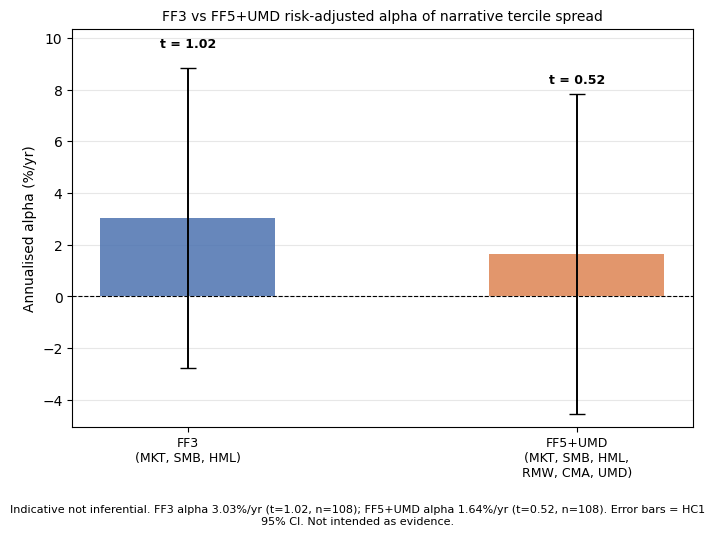

In [9]:
plot_ff3_ff5_comparison(alpha_ff3, alpha_ff5, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
plot_ff3_ff5_comparison(alpha_ff3, alpha_ff5, out_path=png_path)
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 3 terciles leaves 10 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## Reproduction

```
git clone <repo>
cd 05_NarrativeRisk_FF3_FF5_Comparison
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> ff3_ff5_alpha_summary.csv + ff3_ff5_alpha_comparison.pdf
make test-all              # quantlet test suite
```
